# Weather Prediction Model 



## 1. Imports

In [1]:
# ปอเช่ & หยก : สร้างโมเดลพยากรณ์อากาศ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, classification_report)

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RNG = 42


## 2.Bridge สร้าง df_model โดยมีคอลัมน์วันที่รวมอยู่


In [2]:
try:
    df_model = bangkok_df.copy()
    print("Loaded bangkok_df from memory (teammate's notebook)")
except NameError:
    print("bangkok_df not found — loading from Cleaned_Weather_Data.csv (standalone mode)")
    df_model = pd.read_csv("Cleaned_Weather_Data.csv")

    # สร้าง feature columns ที่เพื่อนทำไว้ขึ้นมาใหม่ เพื่อให้ชื่อตรงกัน
    def _season(m):
        if m in [11,12,1,2]: return "Cool"
        if m in [3,4,5]:     return "Hot"
        return "Rainy"
    df_model["season"]   = df_model["month"].apply(_season)
    df_model["pm_lag"]       = df_model["air_quality_PM2.5"].shift(1)
    df_model["wind_lag"]     = df_model["wind_kph"].shift(1)
    df_model["uv_lag"]       = df_model["uv_index"].shift(1)
    df_model["humidity_lag"] = df_model["humidity"].shift(1)
    df_model["cloud_lag"]    = df_model["cloud"].shift(1)
    df_model["Humidity_over_Cloud"]      = df_model["humidity"] / df_model["cloud"]
    df_model["Humidity_over_Temp"]       = df_model["humidity"] / df_model["temperature_celsius"]
    df_model["Humidity_over_Visibility"] = df_model["humidity"] / df_model["visibility_km"]
    df_model["Gust_over_Wind"]           = df_model["gust_kph"] / df_model["wind_kph"]
    df_model["is_day"] = df_model["hour"].apply(lambda x: 1 if 6 <= x <= 18 else 0)

# แปลงเป็น datetime ให้ถูกต้อง + ลบแถวที่วันที่ซ้ำกันออก
df_model["date"] = pd.to_datetime(df_model[["year", "month", "day"]])
df_model = (df_model
            .sort_values("date")
            .drop_duplicates("date", keep="last")
            .reset_index(drop=True))

# อัตราส่วนที่เพื่อนสร้างไว้ (เช่น Gust_over_Wind) อาจได้ inf ถ้าตัวหารเป็น 0 ต้องจัดการด้วย
df_model = df_model.replace([np.inf, -np.inf], np.nan)
num_cols = df_model.select_dtypes(include=[np.number]).columns
df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())

print(f"Rows: {len(df_model)}   |   Date range: {df_model['date'].min().date()} → {df_model['date'].max().date()}")
df_model[["date","temperature_celsius","humidity","wind_kph","precip_mm","condition_text"]].tail()


bangkok_df not found — loading from Cleaned_Weather_Data.csv (standalone mode)
Rows: 704   |   Date range: 2024-05-16 → 2026-04-24


,date,temperature_celsius,humidity,wind_kph,precip_mm,condition_text
699,2026-04-20,37.1,45,19.1,0.0,Clear
700,2026-04-21,36.2,45,18.0,0.0,Cloudy
701,2026-04-22,37.2,42,20.5,0.0,Cloudy
702,2026-04-23,36.2,53,23.4,0.0,Cloudy
703,2026-04-24,35.4,56,20.2,0.0,Cloudy


## 3. Modeling-specific Feature Engineering

Add lag(1,2,3,7) + rolling(3,7) สำหรับตัวแปรอากาศที่เป็นตัวเลขทุกตัว + วันของปีแบบวนซ้ำ


In [3]:
TARGETS_REG = ["temperature_celsius", "humidity", "wind_kph", "precip_mm"]
LAG_COLS    = TARGETS_REG + ["pressure_mb", "cloud", "uv_index"]


def add_model_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["dayofyear"] = d["date"].dt.dayofyear
    d["doy_sin"]   = np.sin(2 * np.pi * d["dayofyear"] / 365.25)
    d["doy_cos"]   = np.cos(2 * np.pi * d["dayofyear"] / 365.25)
    for c in LAG_COLS:
        for lag in [1, 2, 3, 7]:
            d[f"{c}_lag{lag}"] = d[c].shift(lag)
        d[f"{c}_roll3"] = d[c].shift(1).rolling(3).mean()
        d[f"{c}_roll7"] = d[c].shift(1).rolling(7).mean()
    return d


feat = add_model_features(df_model)
print("After feature engineering:", feat.shape)


After feature engineering: (704, 82)


## 4. Time-based Train / Test Split

#แบ่งข้อมูลสำหรับเทรนโมเดล ใช้เวลาเป็นตัวกำหนด
#วันที่ 11–24 เม.ย. 2026 (14 วัน ซึ่งเป็นข้อมูลล่าสุดที่เรามี)


In [4]:
TEST_START = pd.Timestamp("2026-04-11")
TEST_END   = pd.Timestamp("2026-04-24")

lag_cols = [c for c in feat.columns if "_lag" in c or "_roll" in c]
data = feat.dropna(subset=lag_cols).reset_index(drop=True)

train = data[data["date"] <  TEST_START].copy()
test  = data[(data["date"] >= TEST_START) & (data["date"] <= TEST_END)].copy()
print(f"Train: {len(train)} rows   ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test : {len(test)} rows   ({test['date'].min().date()} → {test['date'].max().date()})")

LEAK = set(TARGETS_REG) | {
    "date", "condition_text", "moon_phase",
    "pressure_mb", "cloud", "uv_index", "feels_like_celsius", "visibility_km",
    "gust_kph", "air_quality_Carbon_Monoxide", "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide", "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5", "air_quality_PM10",
    "air_quality_us-epa-index", "air_quality_gb-defra-index",
    "moon_illumination", "condition_name",
    # อัตราส่วนของเพื่อนใช้ค่า ณ เวลา t เลย ทำให้เกิด data leakage ต้องเอาออก
    "Humidity_over_Cloud", "Humidity_over_Temp",
    "Humidity_over_Visibility", "Gust_over_Wind",
}
FEATURES = [c for c in data.columns if c not in LEAK and data[c].dtype != "object"]
print(f"\n{len(FEATURES)} features used for modeling.")


Train: 683 rows   (2024-05-24 → 2026-04-10)
Test : 14 rows   (2026-04-11 → 2026-04-24)

55 features used for modeling.


## 5. Regression Models — 4 targets

In [5]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred) if len(y_true) > 1 else float("nan")
    print(f"  {name:22s} MAE={mae:6.3f}  RMSE={rmse:6.3f}  R²={r2:6.3f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}


reg_results = {}
trained_rf  = {}                   # เก็บโมเดล RF ไว้ใช้ทำ recursive forecast ในขั้นต่อไป

for tgt in TARGETS_REG:
    print(f"\nTarget: {tgt}")
    Xtr, ytr = train[FEATURES], train[tgt]
    Xte, yte = test[FEATURES],  test[tgt]
    rows = []
    for name, model in [
        ("LinearRegression",  LinearRegression()),
        ("Ridge",             Ridge(alpha=1.0, random_state=RNG)),
        ("RandomForest(300)", RandomForestRegressor(n_estimators=300,
                                                   random_state=RNG, n_jobs=-1)),
    ]:
        model.fit(Xtr, ytr)
        rows.append(evaluate(name, yte, model.predict(Xte)))
        if name.startswith("RandomForest"):
            trained_rf[tgt] = model
    reg_results[tgt] = pd.DataFrame(rows)



Target: temperature_celsius
  LinearRegression       MAE= 1.152  RMSE= 1.384  R²=-0.747
  Ridge                  MAE= 1.163  RMSE= 1.409  R²=-0.809
  RandomForest(300)      MAE= 2.570  RMSE= 2.756  R²=-5.921

Target: humidity
  LinearRegression       MAE= 6.411  RMSE= 8.202  R²= 0.160
  Ridge                  MAE= 6.441  RMSE= 8.232  R²= 0.154
  RandomForest(300)      MAE= 7.637  RMSE= 9.447  R²=-0.114

Target: wind_kph
  LinearRegression       MAE= 1.387  RMSE= 1.744  R²=-0.176
  Ridge                  MAE= 1.387  RMSE= 1.750  R²=-0.183
  RandomForest(300)      MAE= 2.221  RMSE= 2.727  R²=-1.873

Target: precip_mm
  LinearRegression       MAE= 0.060  RMSE= 0.082  R²= 0.000
  Ridge                  MAE= 0.058  RMSE= 0.080  R²= 0.000
  RandomForest(300)      MAE= 0.001  RMSE= 0.002  R²= 0.000


## 6.Classification Model : condition_text

In [6]:
le = LabelEncoder()
data["condition_y"]  = le.fit_transform(data["condition_text"])
train["condition_y"] = le.transform(train["condition_text"])
test["condition_y"]  = le.transform(test["condition_text"])

clf = RandomForestClassifier(n_estimators=400, random_state=RNG, n_jobs=-1,
                             class_weight="balanced")
clf.fit(train[FEATURES], train["condition_y"])

# ทดสอบกับข้อมูล 14 วัน (11–24 เม.ย.)
pred_test = clf.predict(test[FEATURES])
print("=== 14-day window (Apr 11–24) ===")
print(f"Accuracy: {accuracy_score(test['condition_y'], pred_test):.3f}")
print(f"Macro F1: {f1_score(test['condition_y'], pred_test, average='macro'):.3f}")

# ทดสอบย้อนหลัง 30 วัน เพื่อเช็กว่าโมเดลยังใช้ได้อยู่ (sanity check)
holdout = train.tail(30)
pred_30 = clf.predict(holdout[FEATURES])
print("\n=== 30-day backtest (sanity) ===")
print(f"Accuracy: {accuracy_score(holdout['condition_y'], pred_30):.3f}")
print(f"Macro F1: {f1_score(holdout['condition_y'], pred_30, average='macro'):.3f}")
print(classification_report(holdout['condition_y'], pred_30,
                            labels=list(range(len(le.classes_))),
                            target_names=le.classes_, zero_division=0))


=== 14-day window (Apr 11–24) ===
Accuracy: 0.643
Macro F1: 0.391

=== 30-day backtest (sanity) ===
Accuracy: 1.000
Macro F1: 1.000
              precision    recall  f1-score   support

       Clear       1.00      1.00      1.00        18
      Cloudy       1.00      1.00      1.00        10
     Drizzle       0.00      0.00      0.00         0
        Rain       0.00      0.00      0.00         0
     Thunder       1.00      1.00      1.00         2

    accuracy                           1.00        30
   macro avg       0.60      0.60      0.60        30
weighted avg       1.00      1.00      1.00        30



## 7.Recursive Forecast — Apr 11 → 24
#ทำนาย → เอาผลไปต่อ → ทำนายวันถัดไป วนไปเรื่อย ๆ


In [7]:
def recursive_forecast(history, models, clf, le, future_dates):
    hist = history.copy()
    out  = []
    for d in future_dates:
        row = {"date": d, "year": d.year, "month": d.month, "day": d.day}
        for c in ["pressure_mb", "cloud", "uv_index"]:
            row[c] = hist[c].iloc[-1]
        for tgt in TARGETS_REG:
            row[tgt] = np.nan
        hist = pd.concat([hist, pd.DataFrame([row])], ignore_index=True)

        feat_step = add_model_features(hist)
        x = feat_step.iloc[[-1]][FEATURES]

        preds   = {tgt: float(models[tgt].predict(x)[0]) for tgt in TARGETS_REG}
        cls_lbl = le.inverse_transform(clf.predict(x))[0]
        for tgt, val in preds.items():
            hist.loc[hist.index[-1], tgt] = val
        out.append({"date": d, **preds, "condition_pred": cls_lbl})
    return pd.DataFrame(out)


history      = df_model[df_model["date"] < TEST_START].copy()
future_dates = pd.date_range(TEST_START, TEST_END, freq="D")
forecast     = recursive_forecast(history, trained_rf, clf, le, future_dates)
forecast


,date,temperature_celsius,humidity,wind_kph,precip_mm,condition_pred
0,2026-04-11,35.286667,48.653333,18.311000,0.000233,Clear
1,2026-04-12,35.154667,49.963333,18.111000,0.000933,Clear
2,2026-04-13,34.984000,49.586667,18.484000,0.000833,Clear
3,2026-04-14,33.857667,50.090000,18.363333,0.000933,Clear
4,2026-04-15,33.780333,50.163333,18.084333,0.001067,Clear
5,2026-04-16,34.340333,49.493333,18.904000,0.000833,Clear
6,2026-04-17,34.221000,51.276667,19.326333,0.000567,Clear
7,2026-04-18,34.247333,48.823333,18.952000,0.000033,Clear
8,2026-04-19,34.200667,48.656667,18.707000,0.000033,Clear
9,2026-04-20,34.209000,48.643333,18.652333,0.000033,Clear


## 8. Forecast vs Actual

In [8]:
actual = df_model[(df_model['date'] >= TEST_START) & (df_model['date'] <= TEST_END)][
    ['date'] + TARGETS_REG + ['condition_text']
].rename(columns={'condition_text': 'condition_actual'})

cmp = forecast.merge(actual, on='date', how='left', suffixes=('_pred', '_actual'))
cmp[['date',
     'temperature_celsius_pred', 'temperature_celsius_actual',
     'humidity_pred',           'humidity_actual',
     'wind_kph_pred',           'wind_kph_actual',
     'precip_mm_pred',          'precip_mm_actual',
     'condition_pred',          'condition_actual']]


,date,temperature_celsius_pred,temperature_celsius_actual,humidity_pred,humidity_actual,wind_kph_pred,wind_kph_actual,precip_mm_pred,precip_mm_actual,condition_pred,condition_actual
0,2026-04-11,35.286667,38.1,48.653333,24,18.311000,18.7,0.000233,0.0,Clear,Clear
1,2026-04-12,35.154667,38.2,49.963333,31,18.111000,19.1,0.000933,0.0,Clear,Clear
2,2026-04-13,34.984000,37.3,49.586667,35,18.484000,21.2,0.000833,0.0,Clear,Clear
3,2026-04-14,33.857667,39.3,50.090000,31,18.363333,22.7,0.000933,0.0,Clear,Clear
4,2026-04-15,33.780333,37.1,50.163333,48,18.084333,19.1,0.001067,0.0,Clear,Clear
5,2026-04-16,34.340333,38.3,49.493333,45,18.904000,19.8,0.000833,0.0,Clear,Clear
6,2026-04-17,34.221000,36.1,51.276667,50,19.326333,22.3,0.000567,0.0,Clear,Cloudy
7,2026-04-18,34.247333,38.0,48.823333,45,18.952000,19.4,0.000033,0.0,Clear,Clear
8,2026-04-19,34.200667,36.3,48.656667,50,18.707000,22.0,0.000033,0.0,Clear,Clear
9,2026-04-20,34.209000,37.1,48.643333,45,18.652333,19.1,0.000033,0.0,Clear,Clear


In [9]:
print("=== Forecast error ===")
for tgt in TARGETS_REG:
    mae = mean_absolute_error(cmp[f'{tgt}_actual'], cmp[f'{tgt}_pred'])
    print(f"{tgt:22s} MAE = {mae:6.3f}")

cls_acc = (cmp['condition_pred'] == cmp['condition_actual']).mean()
n = len(cmp)
print(f"\ncondition_text accuracy = {cls_acc:.2f}  ({int(round(cls_acc*n))}/{n} days)")


=== Forecast error ===
temperature_celsius    MAE =  2.832
humidity               MAE =  8.282
wind_kph               MAE =  1.844
precip_mm              MAE =  0.000

condition_text accuracy = 0.64  (9/14 days)


## 9. Visualizations

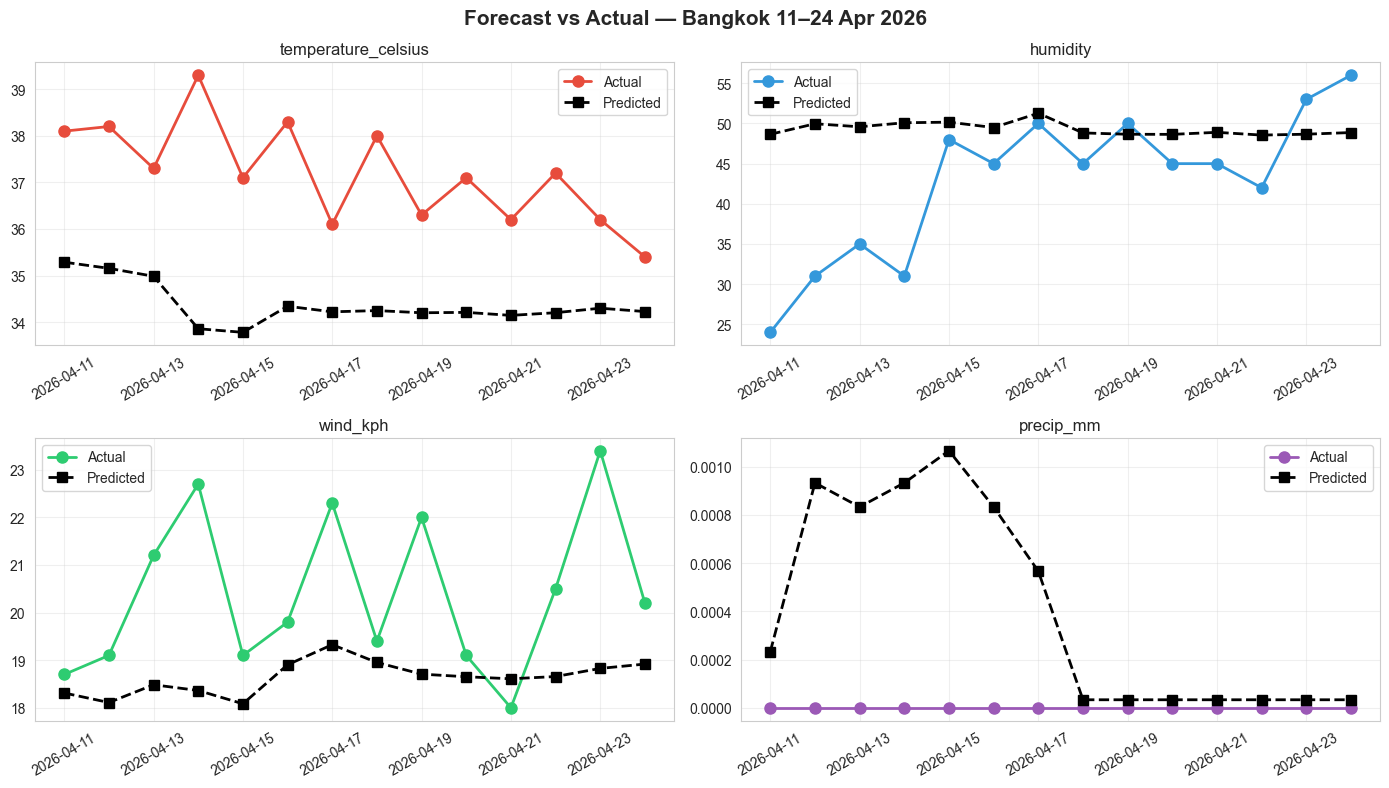

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Forecast vs Actual — Bangkok 11–24 Apr 2026",
             fontsize=15, fontweight='bold')

palette = {'temperature_celsius': '#e74c3c',
           'humidity':            '#3498db',
           'wind_kph':            '#2ecc71',
           'precip_mm':           '#9b59b6'}

for ax, tgt in zip(axes.flat, TARGETS_REG):
    ax.plot(cmp['date'], cmp[f'{tgt}_actual'], 'o-',
            color=palette[tgt], label='Actual', linewidth=2, markersize=8)
    ax.plot(cmp['date'], cmp[f'{tgt}_pred'],  's--',
            color='black', label='Predicted', linewidth=2, markersize=7)
    ax.set_title(tgt); ax.legend(); ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()


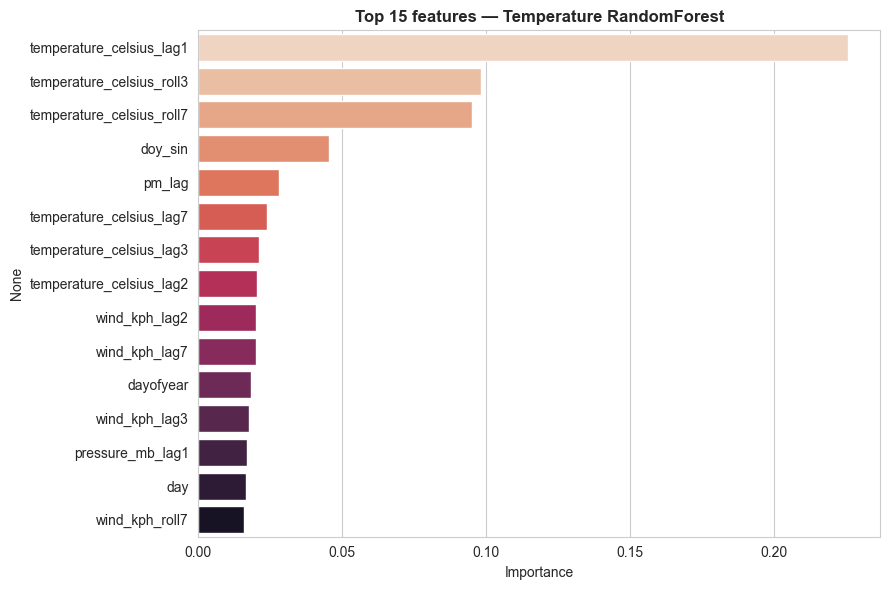

In [11]:
# ดูว่า feature ไหนสำคัญที่สุดในโมเดลพยากรณ์อุณหภูมิ
imp = pd.Series(trained_rf['temperature_celsius'].feature_importances_,
                index=FEATURES).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=imp.values, y=imp.index, palette='rocket_r')
plt.title("Top 15 features — Temperature RandomForest", fontweight='bold')
plt.xlabel("Importance"); plt.tight_layout(); plt.show()
